# Metric vs number-of-subjects (eventclf)

Loads the `.mat` training summaries produced by `train_net.py` (saved in `cluster/outputs/<classification_task>/subject_count/`) and visualizes:

1. Best validation accuracy / loss vs the number of subjects used for training (one row per classification: Visual vs Auditory, Auditory vs Resting, Visual vs Resting, Age). Subject counts with 5 cross-validation folds (25/50/100) are averaged over the folds, with std error bars; larger counts (150-450) come from the single previously-trained runs.
2. Same comparison for test accuracy / loss, loaded from the same `.mat` summaries.
3. Full per-epoch learning curves (train/validation loss & accuracy) for every (classification, network) and subject count, averaged across folds where folds exist.


In [1]:
import glob
import os
import re

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import colors as mcolors
from scipy.io import loadmat

# ---------------------------------------------------------------------------
# 1. CONFIG
# ---------------------------------------------------------------------------
out_dir = '../outputs/'

# classifications: id drives filenames, name drives plot labels
CLASSIFIERS = [
	('eventclf', 'Visual vs Auditory'),
	('mixed_auditory', 'Auditory vs Resting'),
	('mixed_visual', 'Visual vs Resting'),
	('ageclf', 'Age (10-yr bins)'),
]

# naming for legends
# NETS = ['eegnet', 'meegnet', 'mlp', 'vanput', 'vgg']
NETS = ['eegnet', 'meegnet', 'mlp', 'vgg']
net_names = ['EEGNet', 'MEEGNet', 'MLP', 'VGG']

# net_alt = 'eegnet|meegnet|mlp|vanput|vgg'
net_alt = 'eegnet|meegnet|mlp|vgg'


def suffixes(net_alt):
	return rf'(?P<net>{net_alt})_(?P<nsub>\d+).*_ALL'


curve_keys = ['train_losses', 'train_accuracies', 'validation_losses', 'validation_accuracies']
scalar_keys = {
	'validation_accuracy': 'best_val_acc',
	'validation_loss': 'best_val_loss',
	'test_accuracy': 'test_acc',
	'test_loss': 'test_loss',
}

# ---------------------------------------------------------------------------
# 2. Load training summaries. CV runs (5 folds) are averaged per (net, n_sub);
#    single runs are used only for subject counts without cross-validation.
# ---------------------------------------------------------------------------
records = {}  # records[classif][net][n_sub] = aggregated entry
per_fold = {}  # per_fold[classif][net][n_sub][fold] = raw row (before averaging)

for classif, _ in CLASSIFIERS:
	suffix = suffixes(net_alt)
	pattern = re.compile(rf'^{classif}_{suffix}_fold(?P<fold>\d+)\.mat$')
	pattern_single = re.compile(rf'^{classif}_{suffix}\.mat$')
	data_dir = os.path.join(out_dir, classif, 'subject_count')

	upd = per_fold.setdefault(classif, {})
	for path in sorted(glob.glob(os.path.join(data_dir, f'{classif}_*_ALL_fold*.mat'))):
		base = os.path.basename(path)
		m = pattern.match(base)
		if m is None:
			continue
		net, n_sub, fold = m.group('net'), int(m.group('nsub')), int(m.group('fold'))

		data = loadmat(path)
		row = {'path': path, 'n_sub': n_sub, 'fold': fold, 'epochs': int(np.atleast_1d(data['epoch']).squeeze())}
		for key in curve_keys:
			row[key] = np.atleast_1d(data[key]).ravel()
		for key, out in scalar_keys.items():
			row[out] = float(np.atleast_1d(data[key]).squeeze())

		upd.setdefault(net, {}).setdefault(n_sub, {})[fold] = row

	# Average across folds: scalars = mean over folds, curves = element-wise mean
	# truncated to the shortest fold (folds may train for different numbers of epochs).
	rec = records.setdefault(classif, {})
	for net, net_folds in upd.items():
		for n_sub in net_folds:
			folds = net_folds[n_sub]
			flat = list(folds.values())
			nfolds = len(flat)
			common = min(e['epochs'] for e in flat)

			entry = {'n_sub': n_sub, 'cv': True, 'nfolds': nfolds, 'epochs': common}
			for key in scalar_keys.values():
				entry[key] = float(np.mean([e[key] for e in flat]))
			for key in ('best_val_acc', 'best_val_loss', 'test_acc', 'test_loss'):
				entry[f'{key}_std'] = float(np.std([e[key] for e in flat]))
			for key in curve_keys:
				entry[key] = np.mean(np.stack([e[key][:common] for e in flat]), axis=0)

			rec.setdefault(net, {})[n_sub] = entry

	# Single (non-CV) runs, only where no fold summaries exist.
	covered = {(net, n_sub) for net in upd for n_sub in upd[net]}
	for path in sorted(glob.glob(os.path.join(data_dir, f'{classif}_*_ALL.mat'))):
		base = os.path.basename(path)
		if '_fold' in base:
			continue
		m = pattern_single.match(base)
		if m is None:
			continue
		net, n_sub = m.group('net'), int(m.group('nsub'))
		if (net, n_sub) in covered:
			continue

		data = loadmat(path)
		entry = {
			'n_sub': n_sub,
			'cv': False,
			'nfolds': None,
			'best_val_acc_std': np.nan,
			'best_val_loss_std': np.nan,
			'test_acc_std': np.nan,
			'test_loss_std': np.nan,
			'epochs': int(np.atleast_1d(data['epoch']).squeeze()),
		}
		for key, out in scalar_keys.items():
			entry[out] = float(np.atleast_1d(data[key]).squeeze())
		for key in curve_keys:
			entry[key] = np.atleast_1d(data[key]).ravel()

		rec.setdefault(net, {})[n_sub] = entry

# Per-classification overview.
all_nsub = {}  # all_nsub[classif] = sorted subject counts
present_nets = {}  # present_nets[classif] = nets present, in NETS order
for classif, name in CLASSIFIERS:
	all_nsub[classif] = sorted({ns for per_net in records[classif].values() for ns in per_net})
	present_nets[classif] = [n for n in NETS if n in records[classif]]
	print(f'{name} — nets: {present_nets[classif]}, n_sub: {all_nsub[classif]}')


Visual vs Auditory — nets: ['eegnet', 'meegnet', 'mlp', 'vgg'], n_sub: [25, 50, 100, 150, 200, 300, 450]
Auditory vs Resting — nets: ['eegnet', 'meegnet', 'mlp', 'vgg'], n_sub: [25, 50, 100, 150, 200, 300, 450]
Visual vs Resting — nets: ['eegnet', 'meegnet', 'mlp', 'vgg'], n_sub: [25, 50, 100, 150, 200, 300, 450]
Age (10-yr bins) — nets: ['eegnet', 'meegnet', 'mlp', 'vgg'], n_sub: [25, 50, 100, 150, 200, 300, 450]


In [2]:
for classif, name in CLASSIFIERS:
	print(name)
	print(
		f'{"network":<10} {"n_sub":>6} {"nfolds":>6} {"test_acc":>12} {"+/-std":>8} {"test_loss":>14} {"best_epoch":>6}'
	)
	for net in present_nets[classif]:
		for ns in sorted(records[classif][net]):
			e = records[classif][net][ns]
			nf = e['nfolds'] if e['nfolds'] is not None else '-'
			sd = f'{e["test_acc_std"]:+.4f}' if e['test_acc_std'] is not None else '-'
			print(f'{net:<10} {ns:>6} {nf:>6} {e["test_acc"]:>12.4f} {sd:>8} {e["test_loss"]:>14.4f} {e["epochs"]:>6}')


Visual vs Auditory
network     n_sub nfolds     test_acc   +/-std      test_loss best_epoch
eegnet         25      5       0.9216  +0.0038         0.1953    437
eegnet         50      5       0.9367  +0.0020         0.1634    470
eegnet        100      5       0.9417  +0.0021         0.1497    314
eegnet        150      -       0.9501     +nan         0.1279    519
eegnet        200      -       0.9504     +nan         0.1281    403
eegnet        300      -       0.9533     +nan         0.1149    533
eegnet        450      -       0.9577     +nan         0.1082    465
meegnet        25      5       0.9123  +0.0062         0.2191     38
meegnet        50      5       0.9289  +0.0051         0.1793     47
meegnet       100      5       0.9381  +0.0012         0.1620     43
meegnet       150      -       0.9424     +nan         0.1496     45
meegnet       200      -       0.9427     +nan         0.1445     41
meegnet       300      -       0.9455     +nan         0.1367     34
meegnet    

In [3]:
plt.rcParams.update(
	{
		'figure.dpi': 100,
		'savefig.dpi': 300,
		'font.size': 10,
		'axes.titlesize': 11,
		'axes.labelsize': 10,
		'xtick.labelsize': 9,
		'ytick.labelsize': 9,
		'legend.fontsize': 8,
		'axes.grid': True,
		'grid.alpha': 0.3,
		'grid.linestyle': '--',
		'axes.spines.top': False,
		'axes.spines.right': False,
		'figure.constrained_layout.use': True,
	}
)

net_colors = {'eegnet': '#1f77b4', 'meegnet': '#d62728', 'mlp': '#2ca02c', 'vanput': '#9467bd', 'vgg': '#ff7f0e'}

# Chance accuracy per classification: binary tasks at 0.5, age (7 bins of 10 years) at 1/7.
CHANCES = {'eventclf': 0.5, 'mixed_auditory': 0.5, 'mixed_visual': 0.5, 'ageclf': 1 / 7}


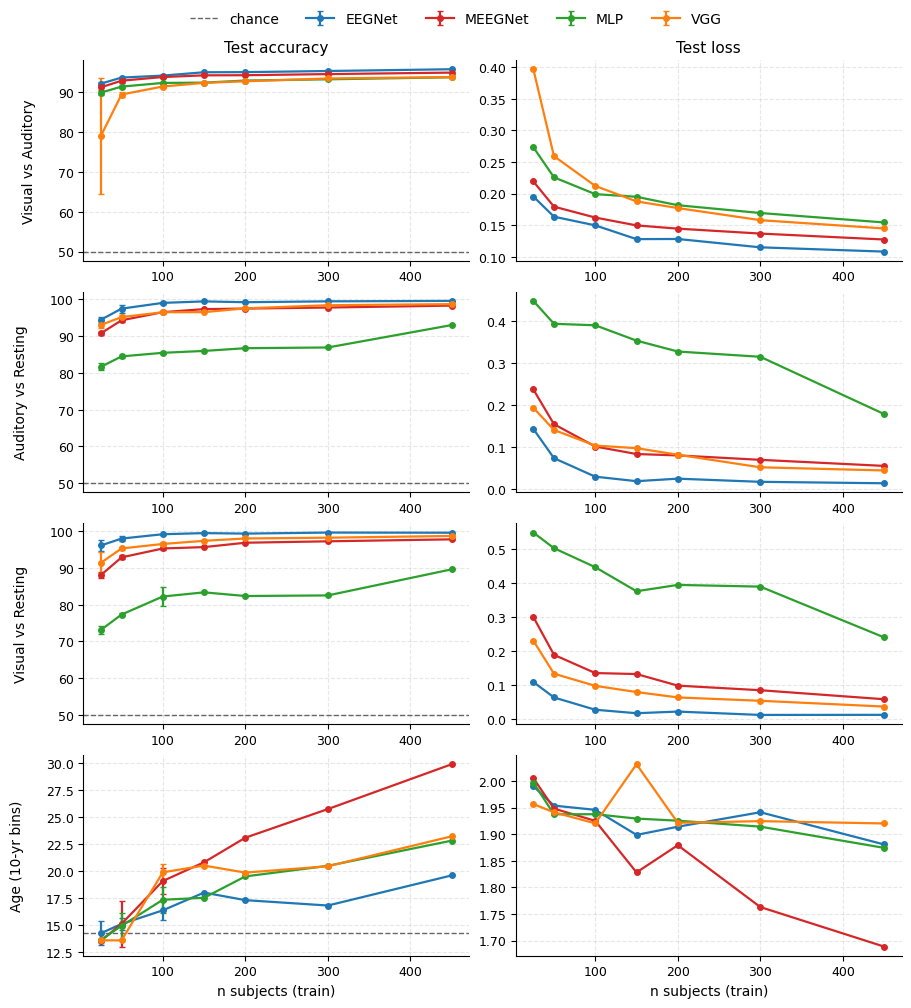

In [4]:
fig, axes = plt.subplots(len(CLASSIFIERS), 2, figsize=(9.0, 2.5 * len(CLASSIFIERS)))

for r, (classif, name) in enumerate(CLASSIFIERS):
	rec = records[classif]
	present = present_nets[classif]

	# Left: test accuracy (CV mean over folds, std error bars; single runs)
	ax = axes[r, 0]
	for i, net in enumerate(present):
		ns_sorted = sorted(rec[net])
		vals = [100 * rec[net][ns]['test_acc'] for ns in ns_sorted]
		errs = [100 * rec[net][ns]['test_acc_std'] for ns in ns_sorted]
		ax.errorbar(
			ns_sorted, vals, yerr=errs, marker='o', ms=4, lw=1.6, capsize=2, color=net_colors[net], label=net_names[i]
		)
	ax.axhline(100 * CHANCES[classif], color='0.4', ls='--', lw=1.0, label='chance')
	ax.set_ylabel(f'{name}\n')
	if r == 0:
		ax.set_title('Test accuracy')

	# Right: test loss
	ax = axes[r, 1]
	for net in present:
		ns_sorted = sorted(rec[net])
		vals = [rec[net][ns]['test_loss'] for ns in ns_sorted]
		ax.plot(ns_sorted, vals, marker='o', ms=4, lw=1.6, color=net_colors[net], label=net)
	# ax.set_ylabel(f'{name}\n')
	if r == 0:
		ax.set_title('Test loss')

for ax in axes[-1, :]:
	ax.set_xlabel('n subjects (train)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc='outside upper center', frameon=False, framealpha=1, fontsize=10)
fig.savefig('metric_vs_nsub_test.png', bbox_inches='tight')
plt.show()


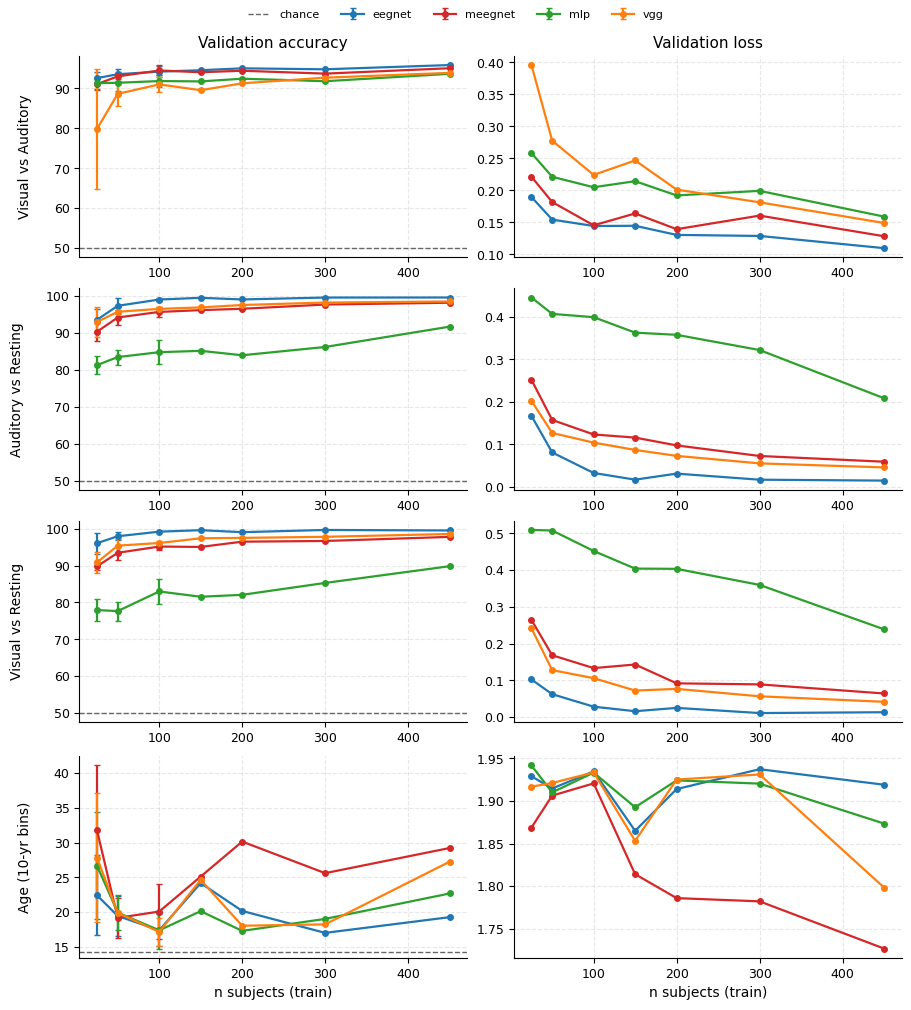

In [5]:
fig, axes = plt.subplots(len(CLASSIFIERS), 2, figsize=(9.0, 2.5 * len(CLASSIFIERS)))

for r, (classif, name) in enumerate(CLASSIFIERS):
	rec = records[classif]
	present = present_nets[classif]

	# Left: validation accuracy (CV mean over folds, std error bars; single runs)
	ax = axes[r, 0]
	for net in present:
		ns_sorted = sorted(rec[net])
		vals = [100 * rec[net][ns]['best_val_acc'] for ns in ns_sorted]
		errs = [100 * rec[net][ns]['best_val_acc_std'] for ns in ns_sorted]
		ax.errorbar(ns_sorted, vals, yerr=errs, marker='o', ms=4, lw=1.6, capsize=2, color=net_colors[net], label=net)
	ax.axhline(100 * CHANCES[classif], color='0.4', ls='--', lw=1.0, label='chance')
	ax.set_ylabel(f'{name}\n')
	if r == 0:
		ax.set_title('Validation accuracy')

	# Right: validation loss
	ax = axes[r, 1]
	for net in present:
		ns_sorted = sorted(rec[net])
		vals = [rec[net][ns]['best_val_loss'] for ns in ns_sorted]
		ax.plot(ns_sorted, vals, marker='o', ms=4, lw=1.6, color=net_colors[net], label=net)
	# ax.set_ylabel(f'{name}\n')
	if r == 0:
		ax.set_title('Validation loss')

for ax in axes[-1, :]:
	ax.set_xlabel('n subjects (train)')

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc='outside upper center', frameon=False, framealpha=1)
fig.savefig('metric_vs_nsub.png', bbox_inches='tight')
plt.show()


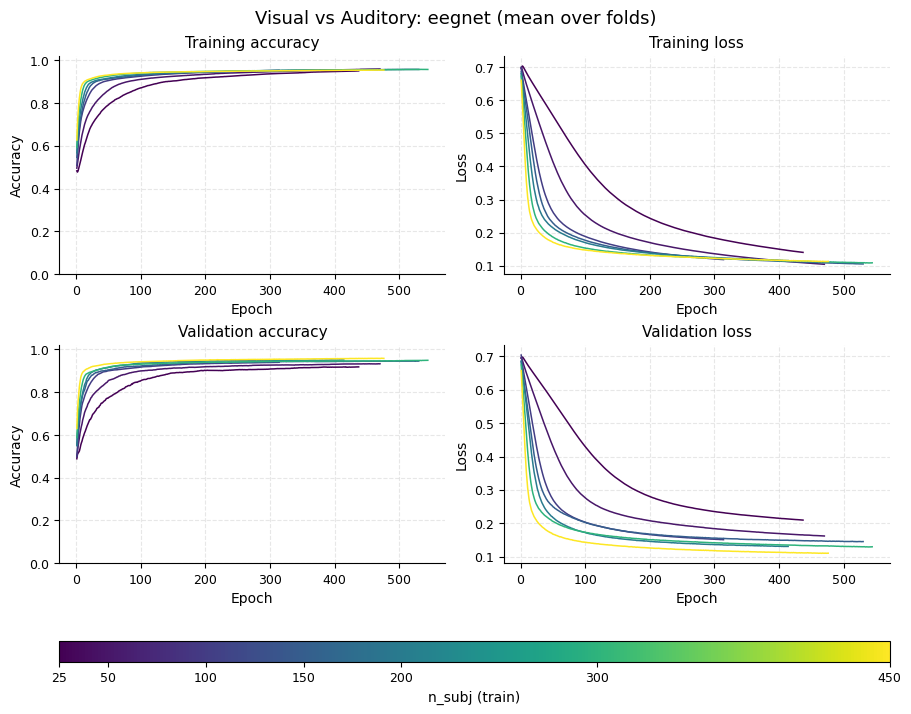

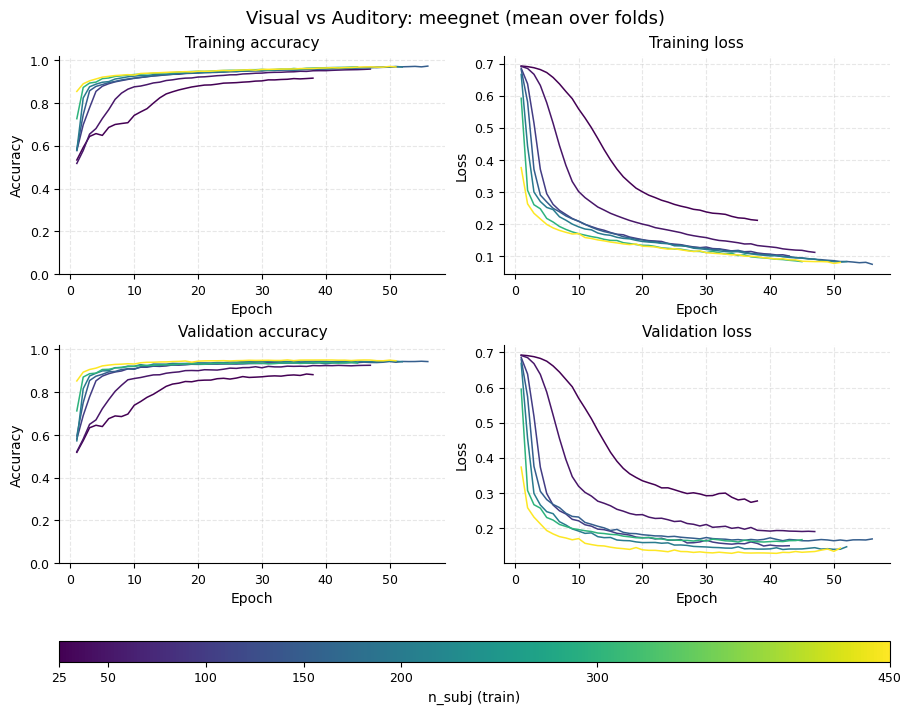

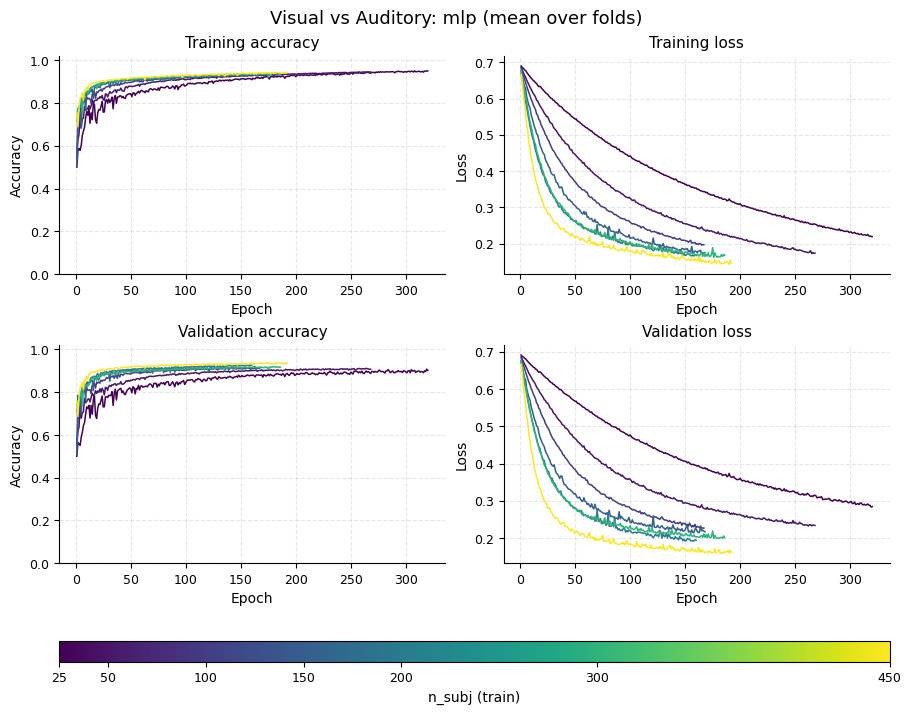

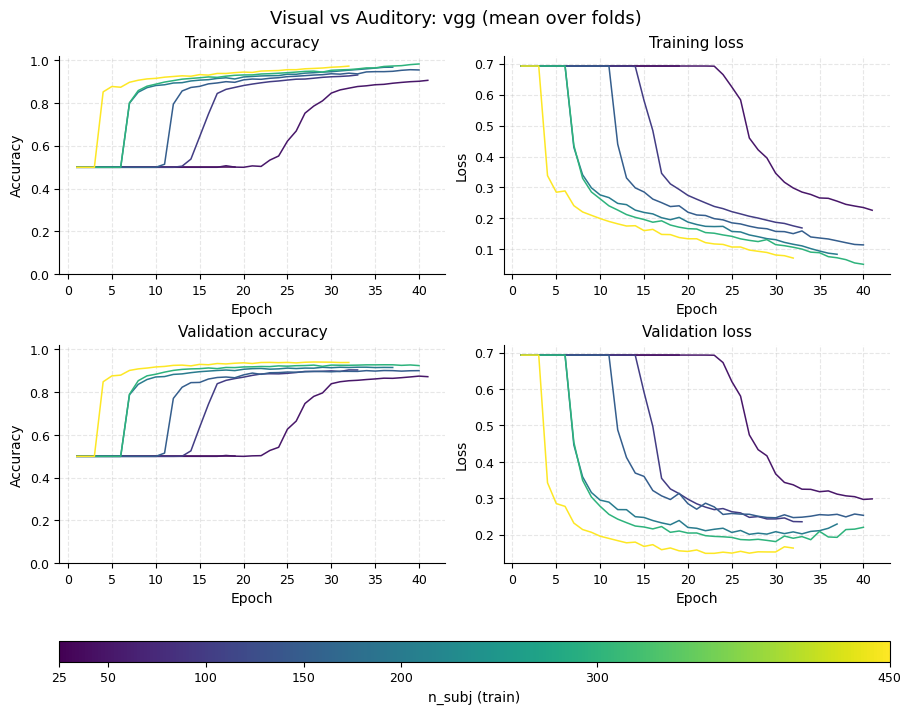

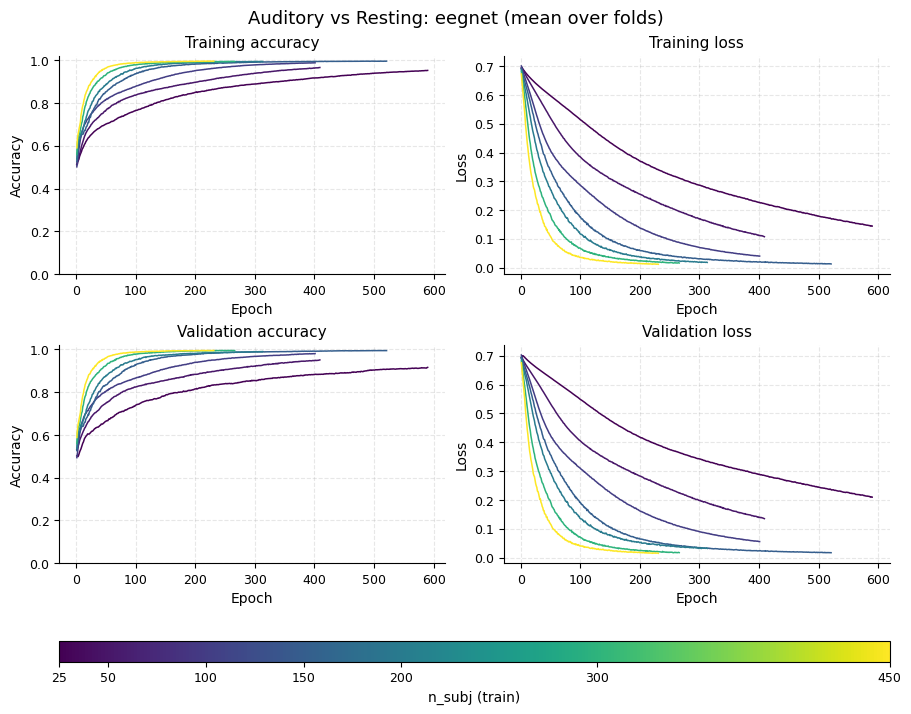

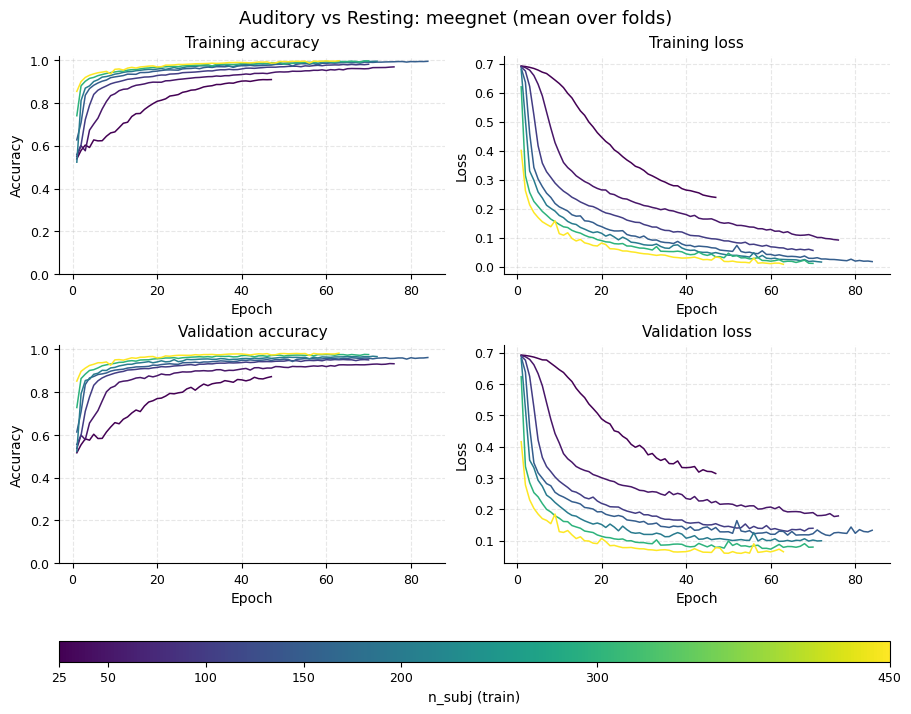

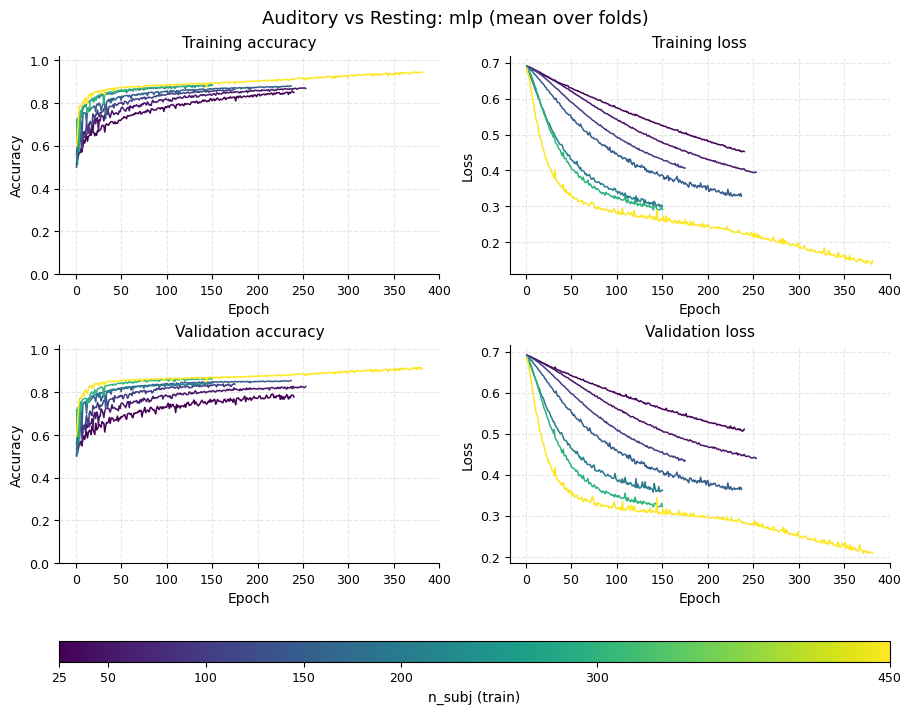

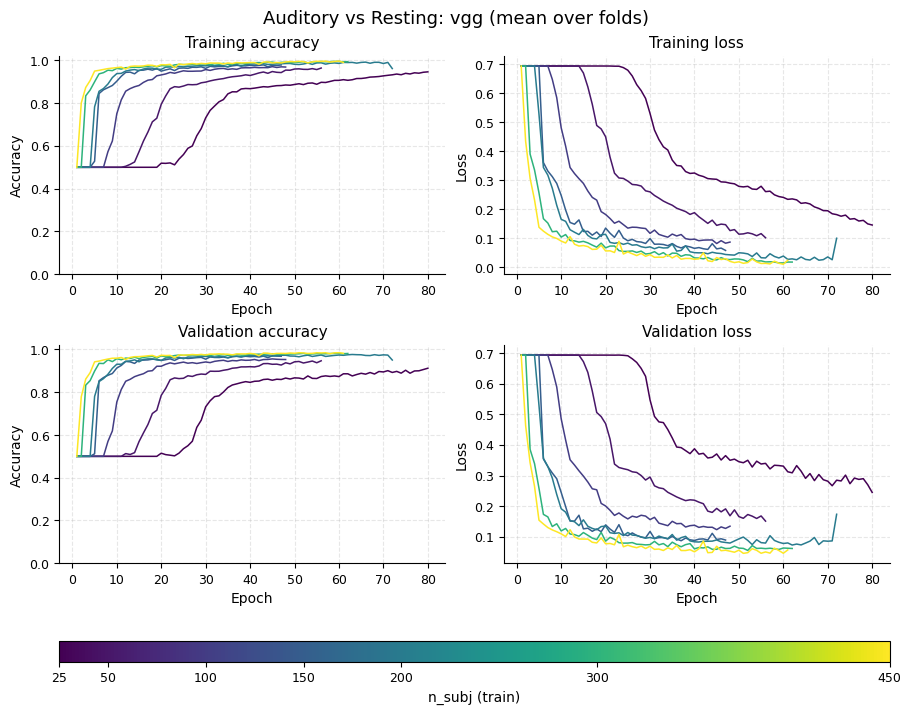

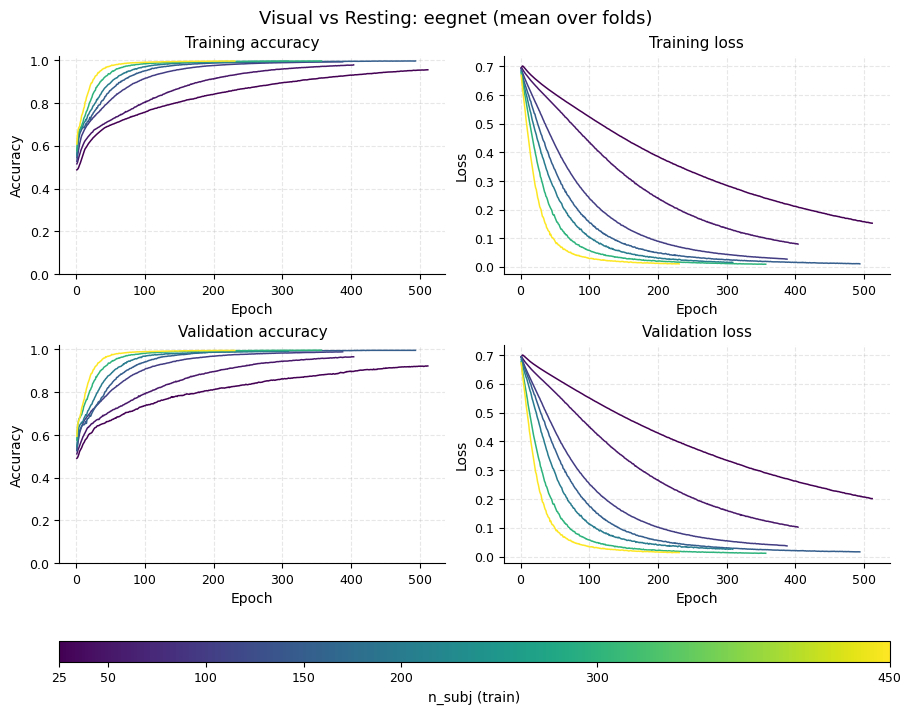

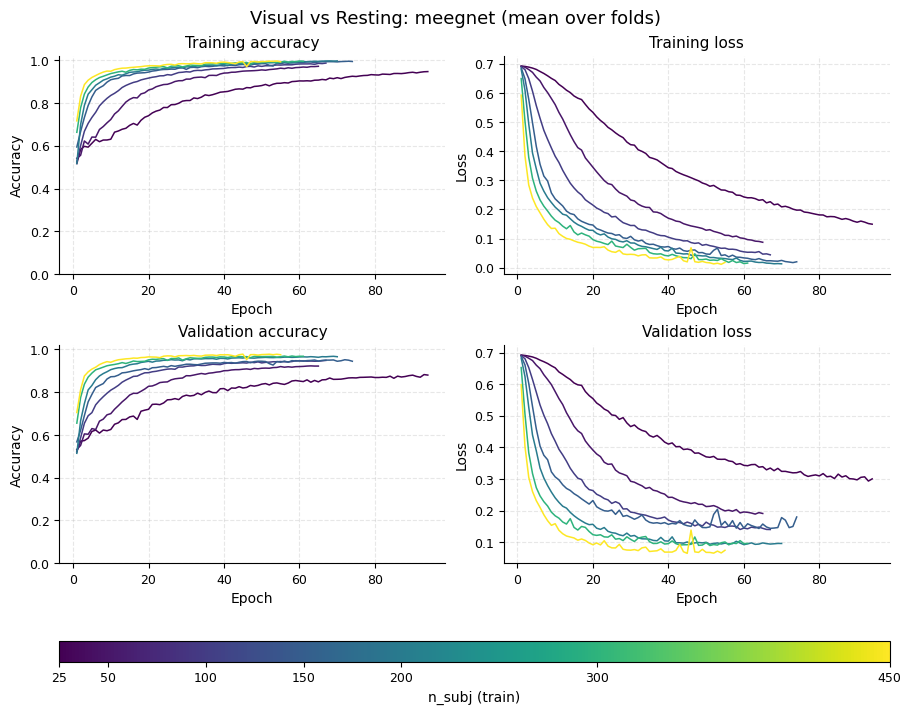

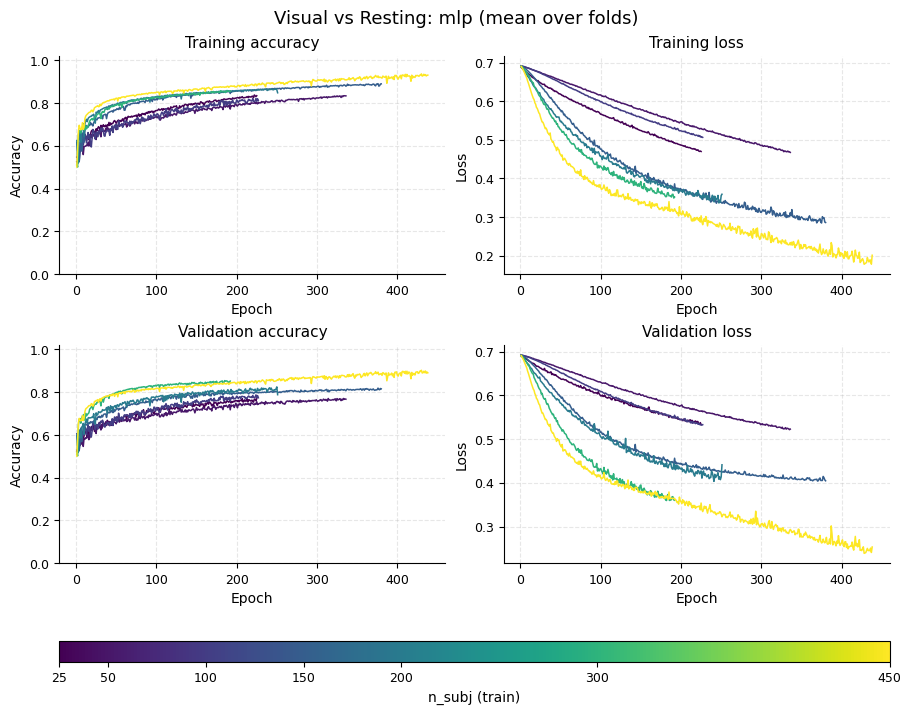

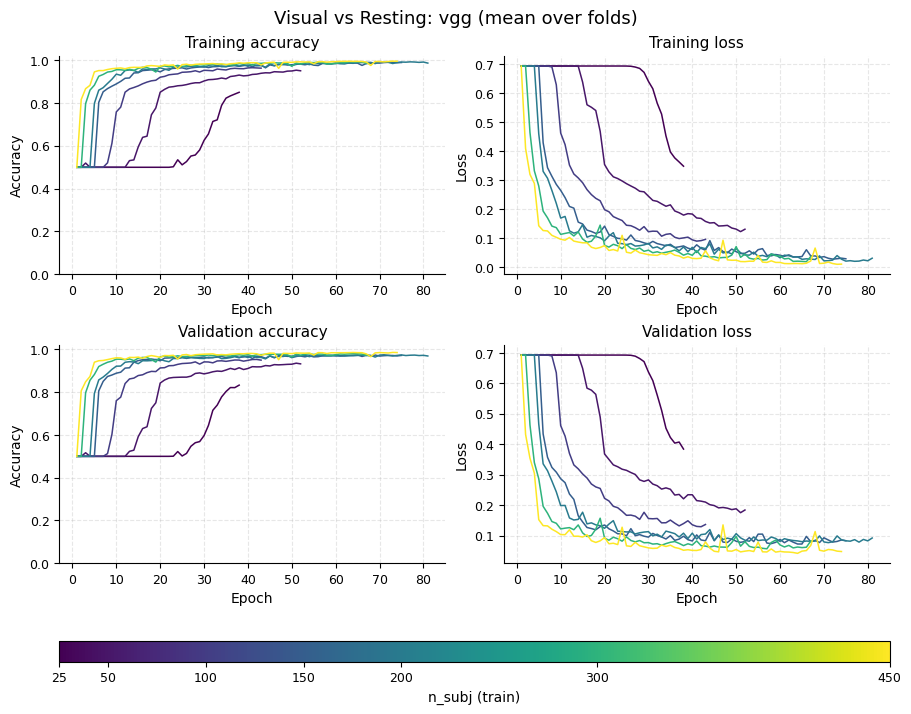

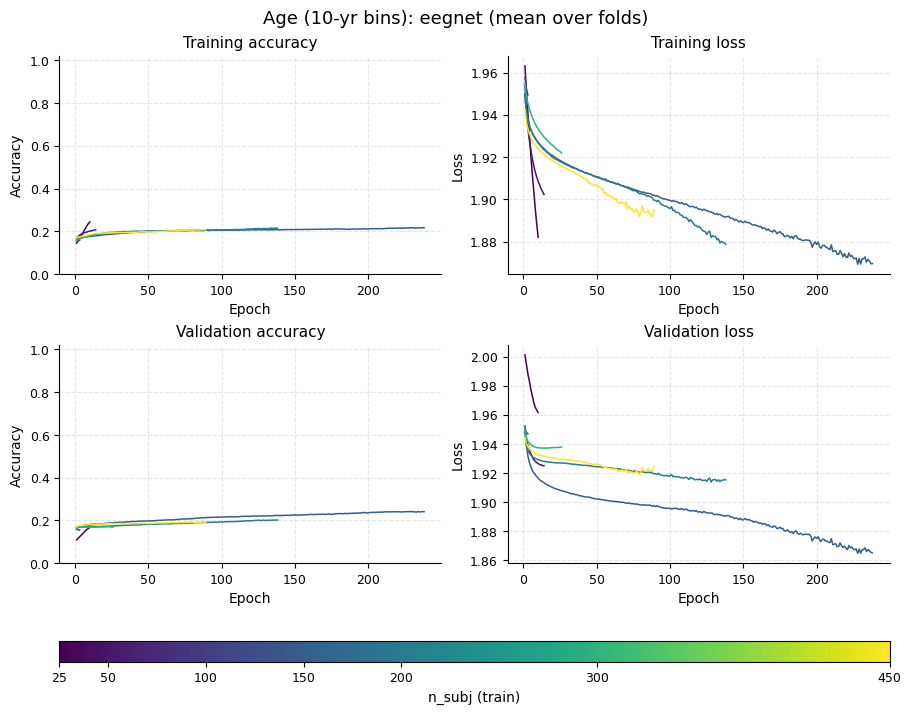

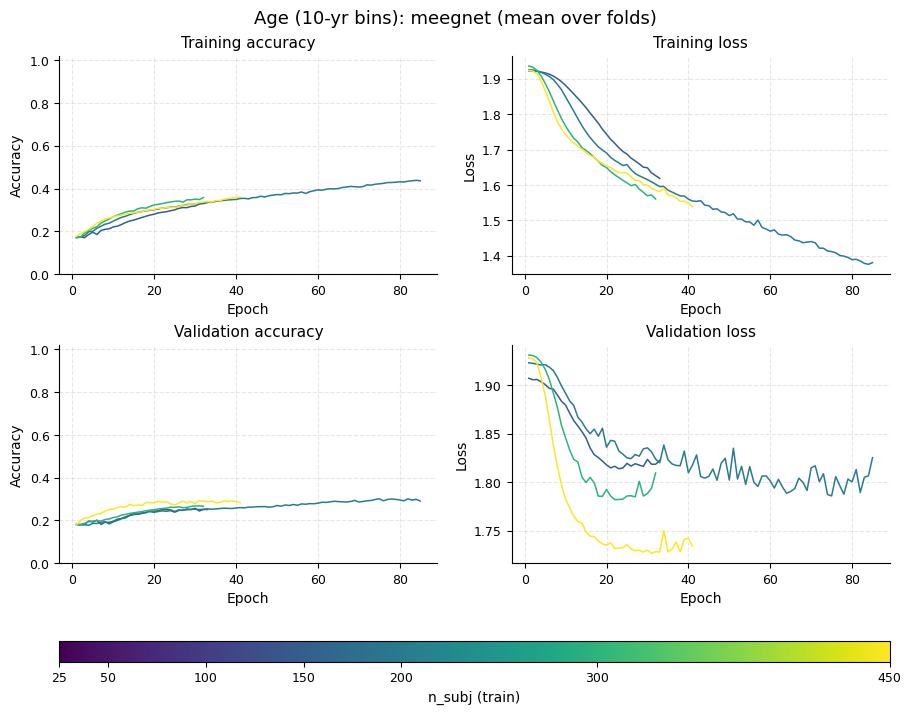

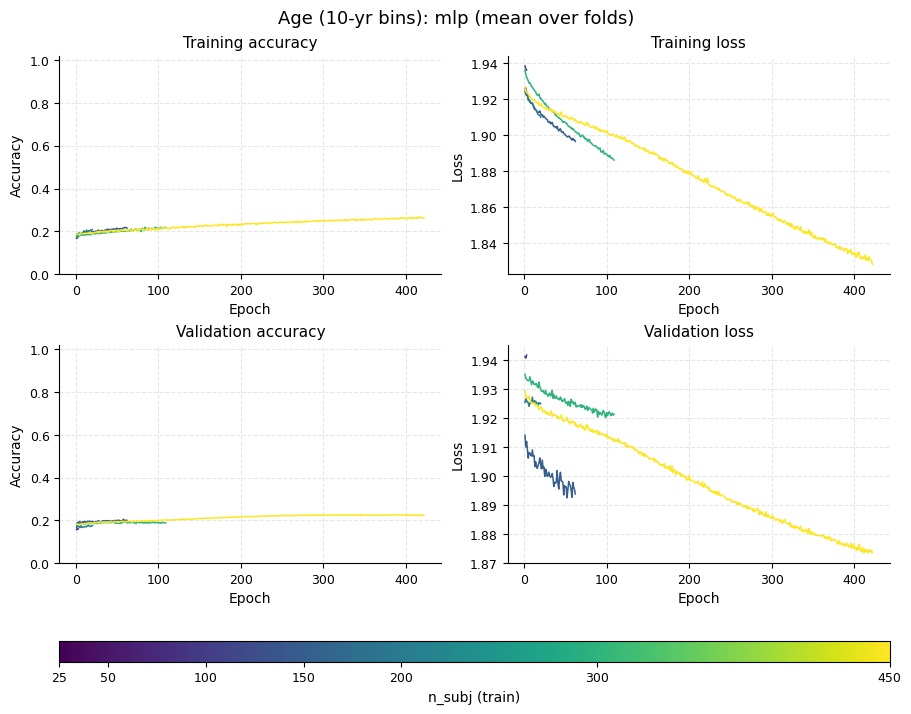

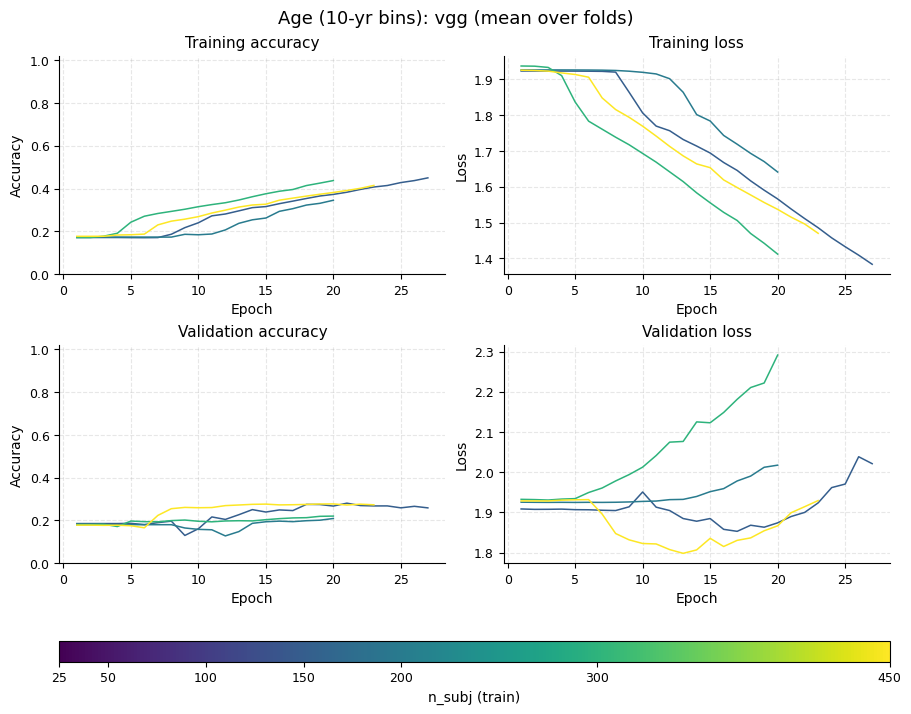

In [6]:
cmap = plt.get_cmap('viridis')

panels = [
	('train_accuracies', 'Training accuracy', 'accuracy'),
	('train_losses', 'Training loss', 'loss'),
	('validation_accuracies', 'Validation accuracy', 'accuracy'),
	('validation_losses', 'Validation loss', 'loss'),
]

for classif, name in CLASSIFIERS:
	for net in present_nets[classif]:
		net_subs = sorted(records[classif][net])
		norm = mcolors.Normalize(vmin=min(net_subs), vmax=max(net_subs))  # per-figure norm

		fig, axes = plt.subplots(2, 2, figsize=(9.0, 7.0))
		axes = axes.ravel()

		for ax, (key, title, kind) in zip(axes, panels):
			for ns in net_subs:
				curve = records[classif][net][ns][key]
				epochs = np.arange(1, len(curve) + 1)
				ax.plot(epochs, curve, color=cmap(norm(ns)), lw=1.1)
			ax.set_xlabel('Epoch')
			ax.set_ylabel(kind.capitalize())
			ax.set_title(title)
			if kind == 'accuracy':
				ax.set_ylim(0, 1.02)

		fig.suptitle(f'{name}: {net} (mean over folds)', fontsize=13)

		# Fig-level colorbar legend for n_sub.
		sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
		sm.set_array([])
		cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.06, aspect=40)
		cbar.set_label('n_subj (train)')
		cbar.set_ticks(net_subs)

		fig.savefig(f'learning_curves_{classif}_{net}_2x2.png', bbox_inches='tight')
		plt.show()
